In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

In [5]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [7]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = ["created_at", "updated_at", "paid_at", "from_date", "to_date",
                    "cash_request_created_at", "cash_request_updated_at",
                    "reimbursement_date", "cash_request_received_date",
                    "money_back_date", "send_at", "moderated_at"]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)



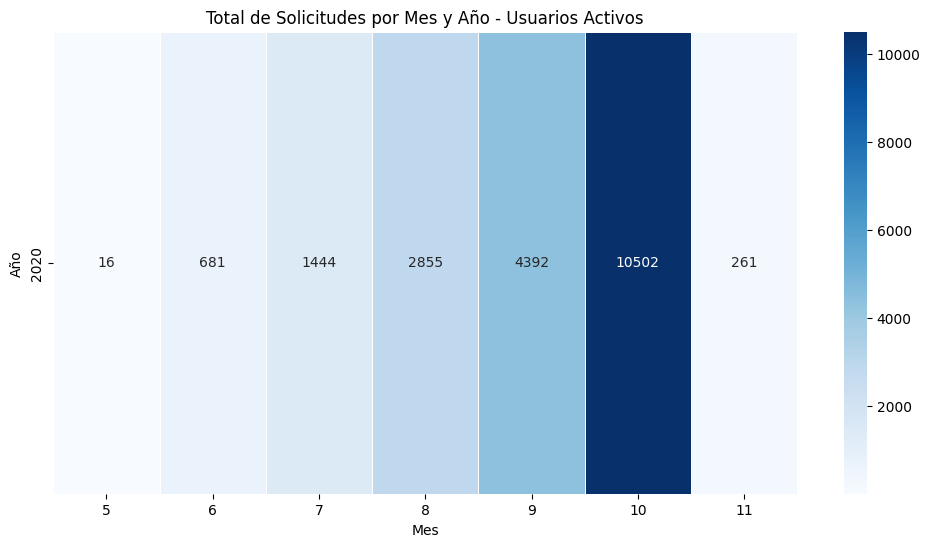

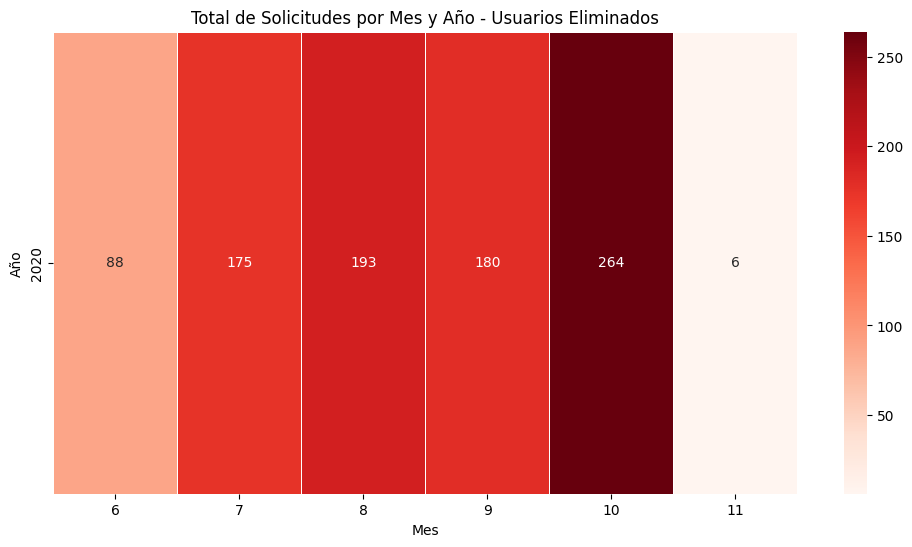

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes por mes y año en usuarios activos
solicitudes_por_mes_activos = usuarios_activos.groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y año en usuarios eliminados
solicitudes_por_mes_eliminados = usuarios_eliminados.groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


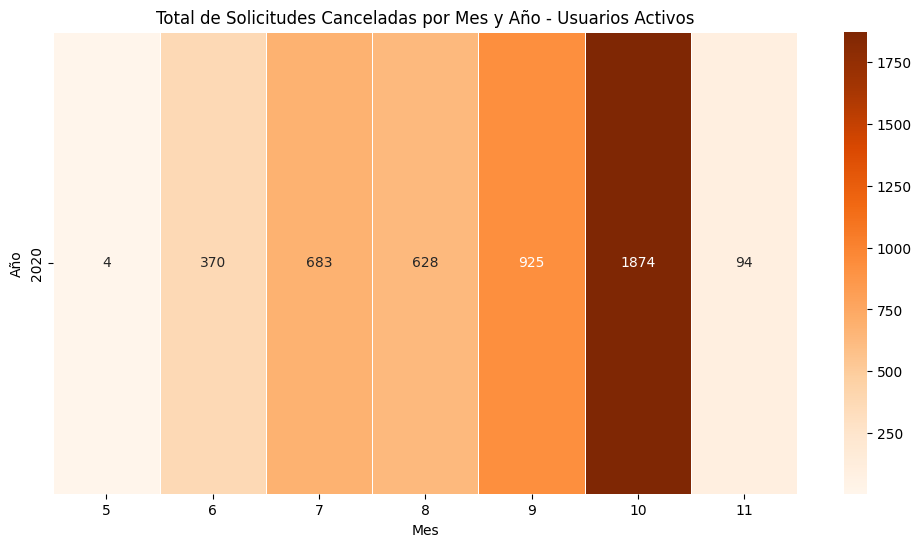

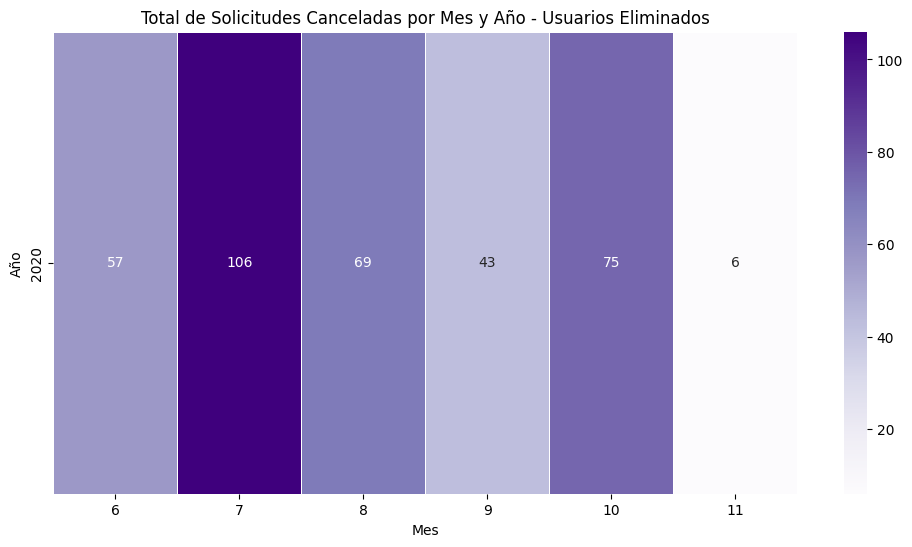

In [10]:
# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios activos
canceladas_por_mes_activos = usuarios_activos[usuarios_activos["status"] == "cancelled"].groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios eliminados
canceladas_por_mes_eliminados = usuarios_eliminados[usuarios_eliminados["status"] == "cancelled"].groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para solicitudes canceladas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para solicitudes canceladas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


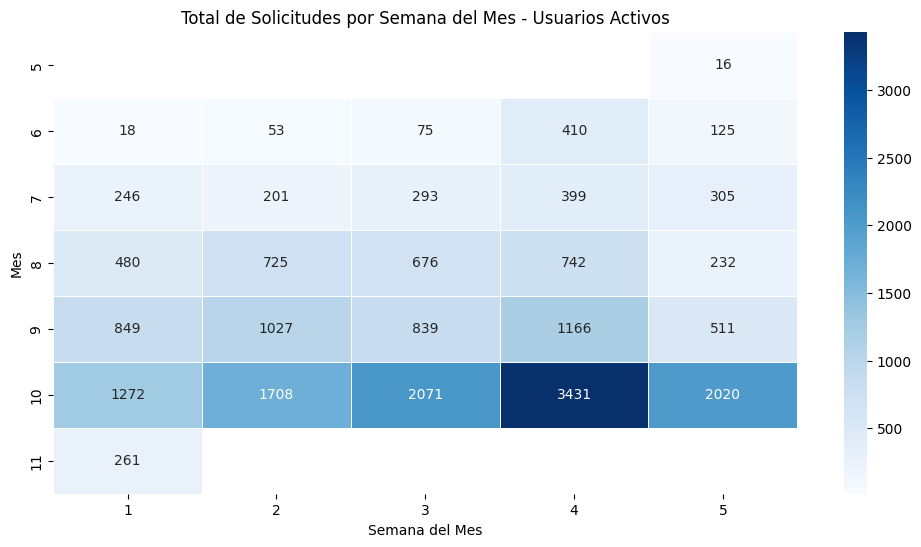

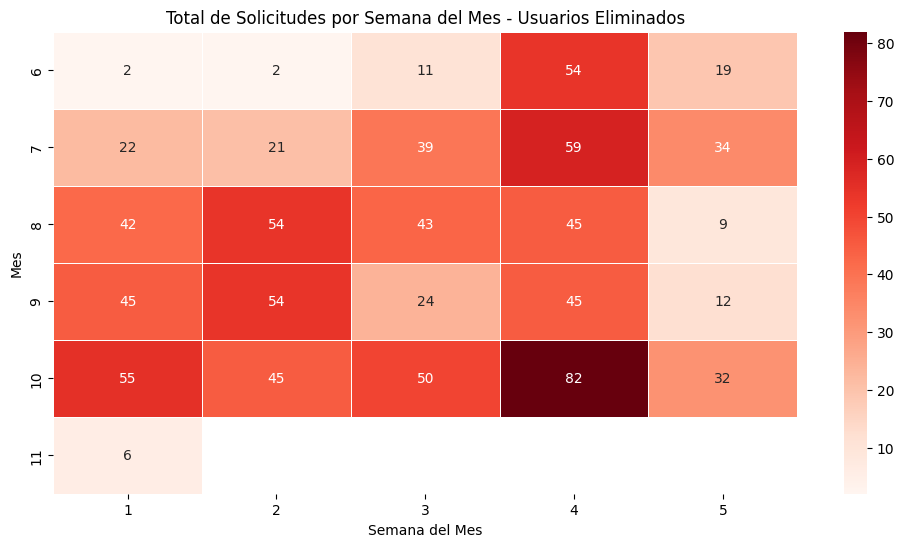

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una nueva columna con la semana dentro del mes
usuarios_activos["semana_mes_solicitud"] = usuarios_activos["created_at"].dt.day // 7 + 1
usuarios_eliminados["semana_mes_solicitud"] = usuarios_eliminados["created_at"].dt.day // 7 + 1

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios activos
solicitudes_por_semana_mes_activos = usuarios_activos.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios eliminados
solicitudes_por_semana_mes_eliminados = usuarios_eliminados.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Crear la matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


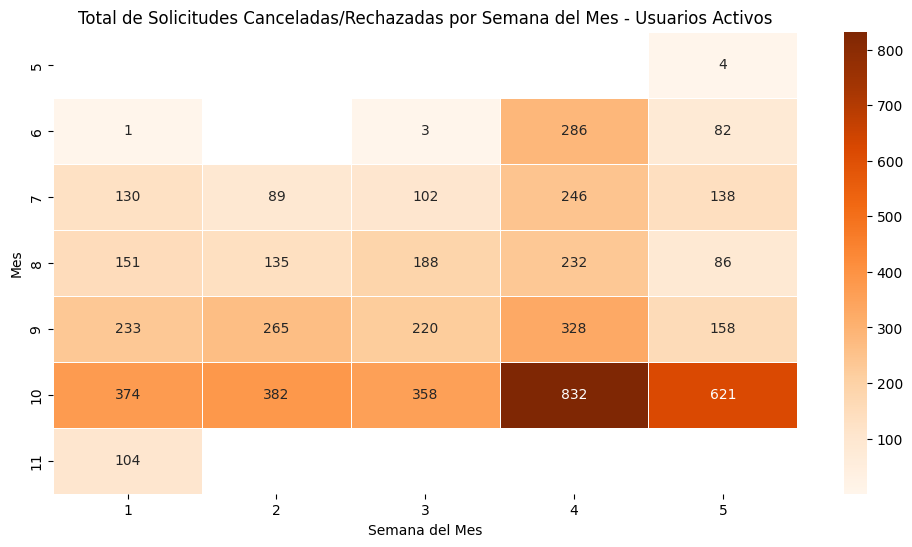

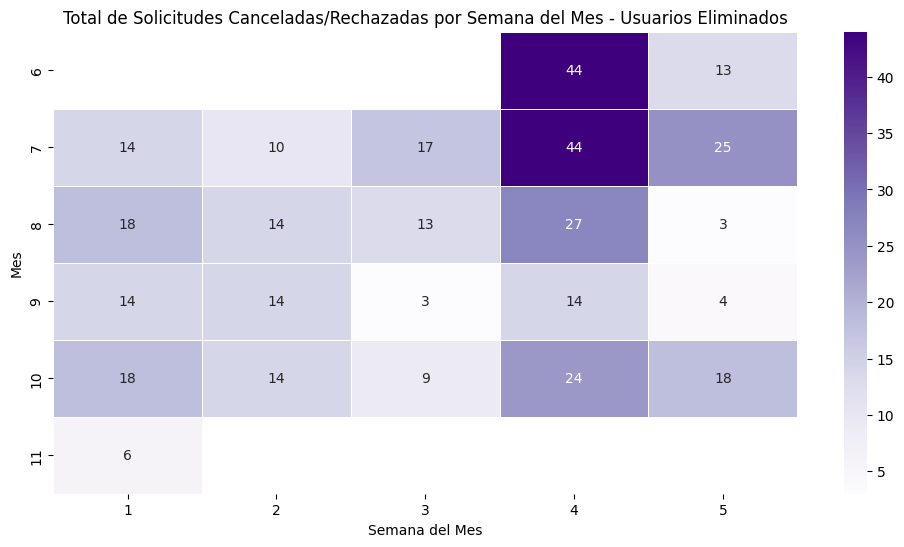

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios activos
canceladas_rechazadas_por_semana_mes_activos = usuarios_activos[
    usuarios_activos["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios eliminados
canceladas_rechazadas_por_semana_mes_eliminados = usuarios_eliminados[
    usuarios_eliminados["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["deleted_account_id"].count().unstack()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()
